In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [2]:
!ls /Users/alexdimofte/workspace/northeastern/data/convinced_classifier

eval_heldout360_all.csv       val1_random20.csv
eval_heldout360_all.meta.json val1_random20.meta.json
train_all.csv                 val2_jlens20.csv
train_all.meta.json           val2_jlens20.meta.json
train_random20.csv            val_all.csv
train_random20.meta.json      val_all.meta.json


In [3]:
root_folder = "/Users/alexdimofte/workspace/northeastern/data/convinced_classifier"
# df_train = pd.read_csv(f"{root_folder}/train_random20.csv")
df_train = pd.read_csv(f"{root_folder}/train_all.csv")
# df_val_rand = pd.read_csv(f"{root_folder}/val1_random20.csv")
df_val = pd.read_csv(f"{root_folder}/val_all.csv")
# df_val_jlens = pd.read_csv(f"{root_folder}/val2_jlens20.csv")
eval_heldout = pd.read_csv(f"{root_folder}/eval_heldout360_all.csv")

In [4]:
len(df_train),len(df_val), len(eval_heldout)
nr_columns_train = len(df_train.columns)
nr_columns_train == len(df_val.columns), nr_columns_train == len(eval_heldout.columns)
nr_columns_train, sum(df_train.columns == df_val.columns)/nr_columns_train, sum(df_train.columns == eval_heldout.columns)/nr_columns_train

(49, np.float64(1.0), np.float64(1.0))

In [5]:
df_train.columns

Index(['name', 'size', 'complexity', 'run', 'step', 'reasoning_pos', 'abs_pos',
       'token', 'arm', 'dir_logmass_L7', 'dir_logmass_L8', 'dir_logmass_L9',
       'dir_logmass_L10', 'dir_logmass_L11', 'dir_logmass_L12',
       'dir_logmass_L13', 'dir_logmass_L14', 'dir_logmass_L15',
       'dir_logmass_L16', 'dir_logmass_L17', 'dir_logmass_L18',
       'dir_logmass_L19', 'dir_logmass_L20', 'dir_logmass_L21',
       'dir_logmass_L22', 'dir_logmass_L23', 'dir_prob_L15',
       'is_direction_token', 'pick_score', 'is_convinced', 'cohort',
       'convinced_idx', 'first_correct_idx', 'rel_sentence',
       'n_reasoning_tokens', 'reasoning_frac', 'n_sentences', 'sentence_idx',
       'pos_in_sentence', 'sentence_len', 'sentence_frac', 'is_sentence_end',
       'x_sentence', 'convinced_reasoning_frac', 'n_switches',
       'sent_model_action', 'sent_correct', 'final_action', 'ground_truth'],
      dtype='object')

In [6]:
df_train.cohort.groupby(df_train.cohort).count()

cohort
immediate     64251
never           866
normal       711074
Name: cohort, dtype: int64

Text(0.5, 1.0, 'Evaluation Heldout Set')

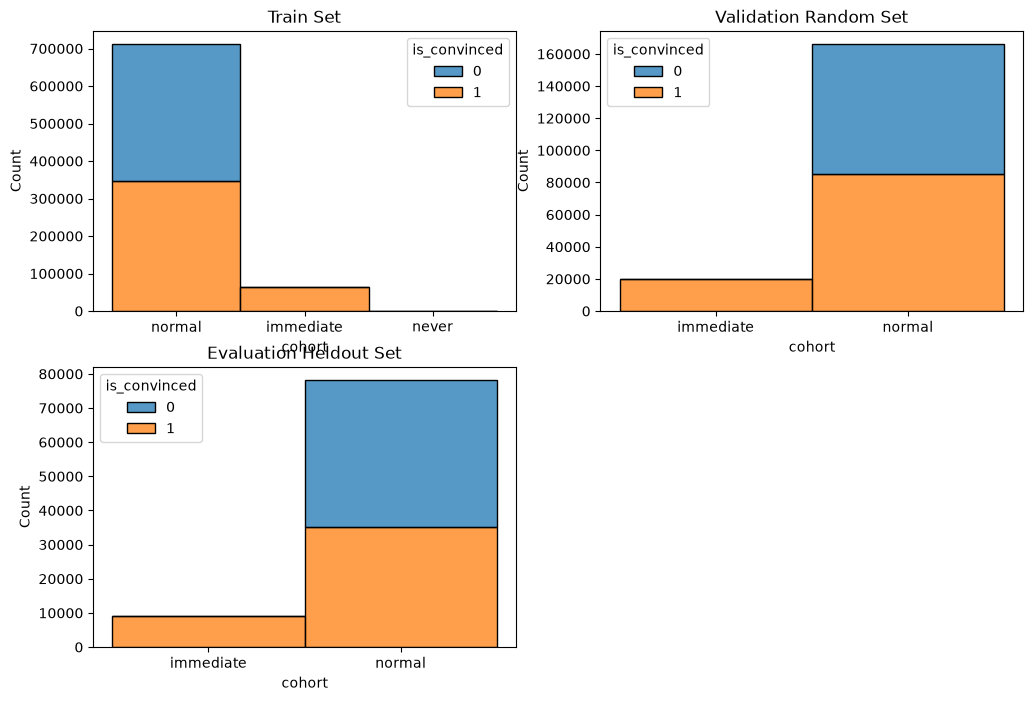

In [7]:
# plot the distribution of the target variable for each dataset
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(data=df_train, x='cohort', hue='is_convinced', multiple='stack')
plt.title('Train Set')
plt.subplot(2, 2, 2)
sns.histplot(data=df_val, x='cohort', hue='is_convinced', multiple='stack')
plt.title('Validation Random Set')
plt.subplot(2, 2, 3)
sns.histplot(data=eval_heldout, x='cohort', hue='is_convinced', multiple='stack')
plt.title('Evaluation Heldout Set')

Text(0.5, 1.0, 'Evaluation Heldout Set')

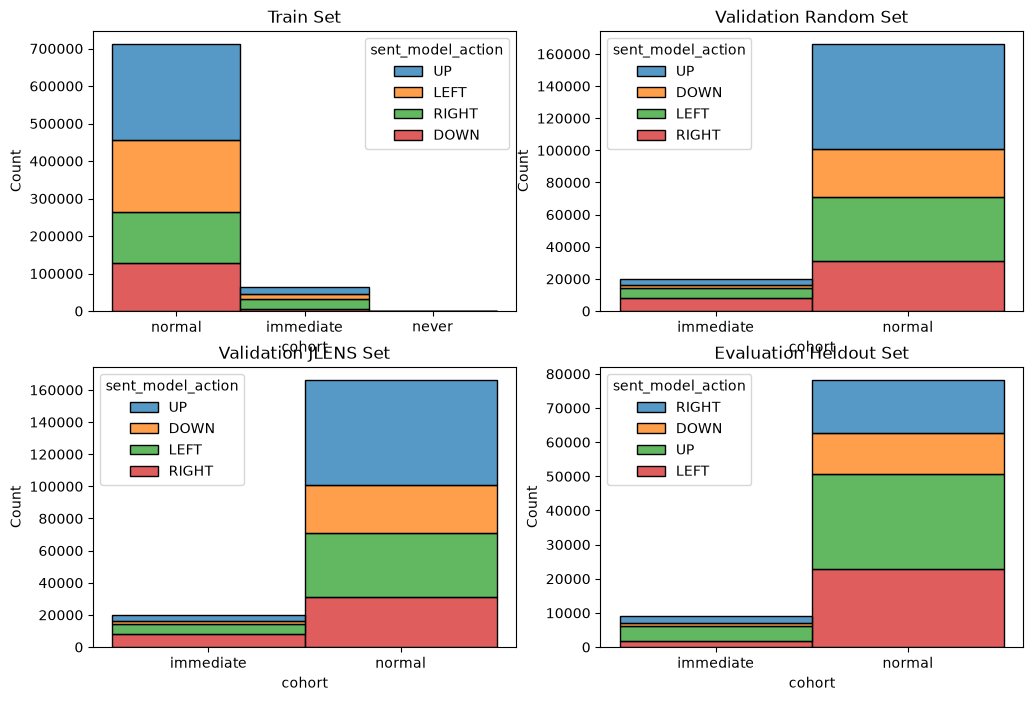

In [8]:
# same but with sent_model_action
# plot the distribution of the target variable for each dataset
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(data=df_train, x='cohort', hue='sent_model_action', multiple='stack')
plt.title('Train Set')
plt.subplot(2, 2, 2)
sns.histplot(data=df_val, x='cohort', hue='sent_model_action', multiple='stack')
plt.title('Validation Random Set')
plt.subplot(2, 2, 3)
sns.histplot(data=df_val, x='cohort', hue='sent_model_action', multiple='stack')
plt.title('Validation JLENS Set')
plt.subplot(2, 2, 4)
sns.histplot(data=eval_heldout, x='cohort', hue='sent_model_action', multiple='stack')
plt.title('Evaluation Heldout Set')

In [9]:
# Filtering to normal cohort only
df_train_normal = df_train[df_train['cohort'] == 'normal']
df_val_normal = df_val[df_val['cohort'] == 'normal']
eval_heldout_normal = eval_heldout[eval_heldout['cohort'] == 'normal']

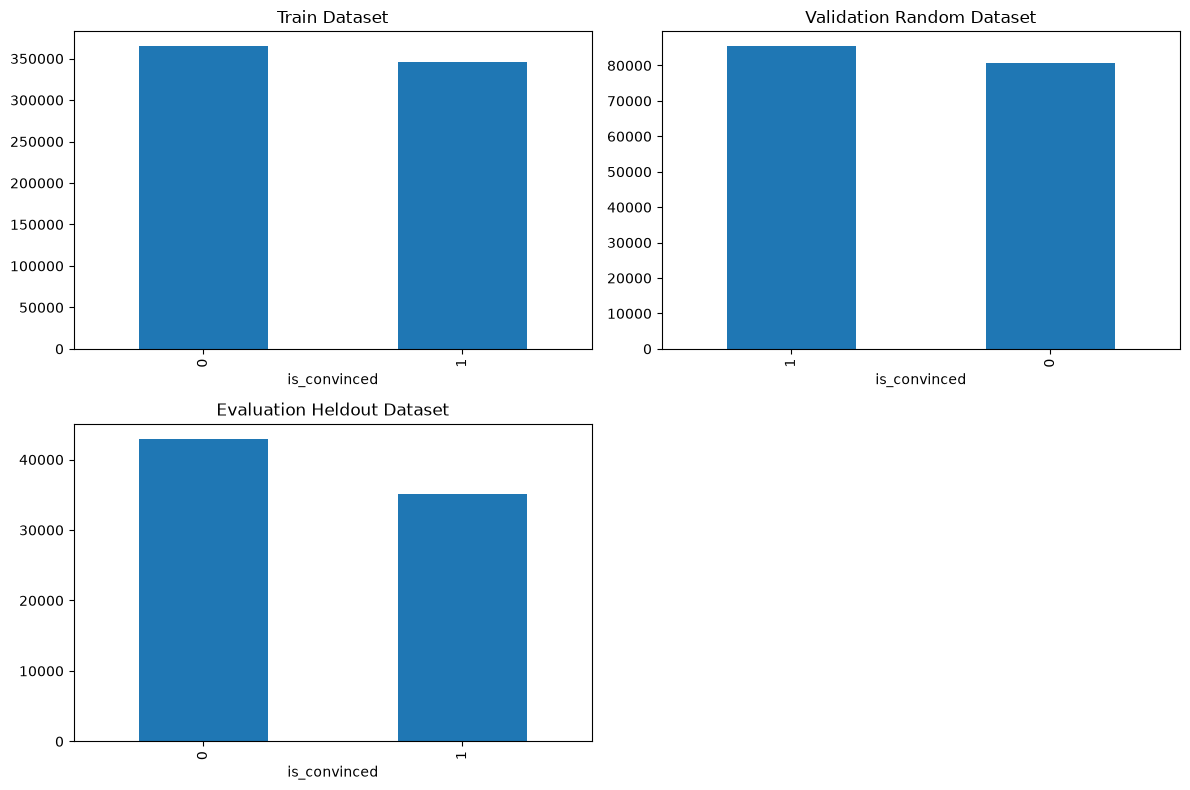

In [10]:
# plot the distribution of the target variable for each dataset
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
df_train_normal.is_convinced.value_counts().plot(kind='bar', title='Train Dataset')
plt.subplot(2, 2, 2)
df_val_normal.is_convinced.value_counts().plot(kind='bar', title='Validation Random Dataset')
plt.subplot(2, 2, 3)
eval_heldout_normal.is_convinced.value_counts().plot(kind='bar', title='Evaluation Heldout Dataset')
plt.tight_layout()

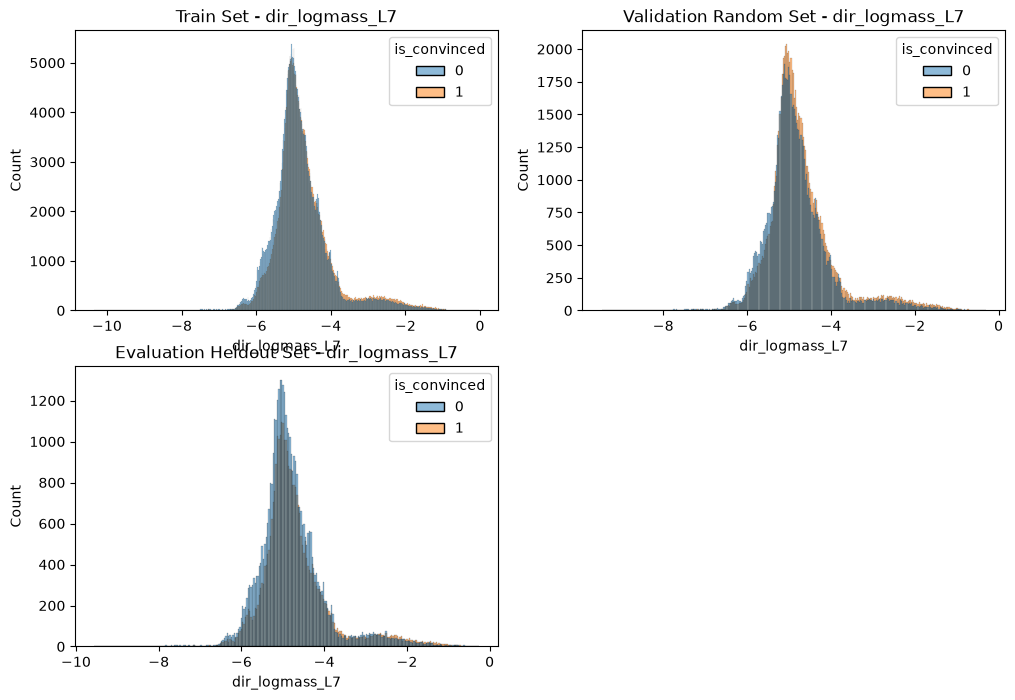

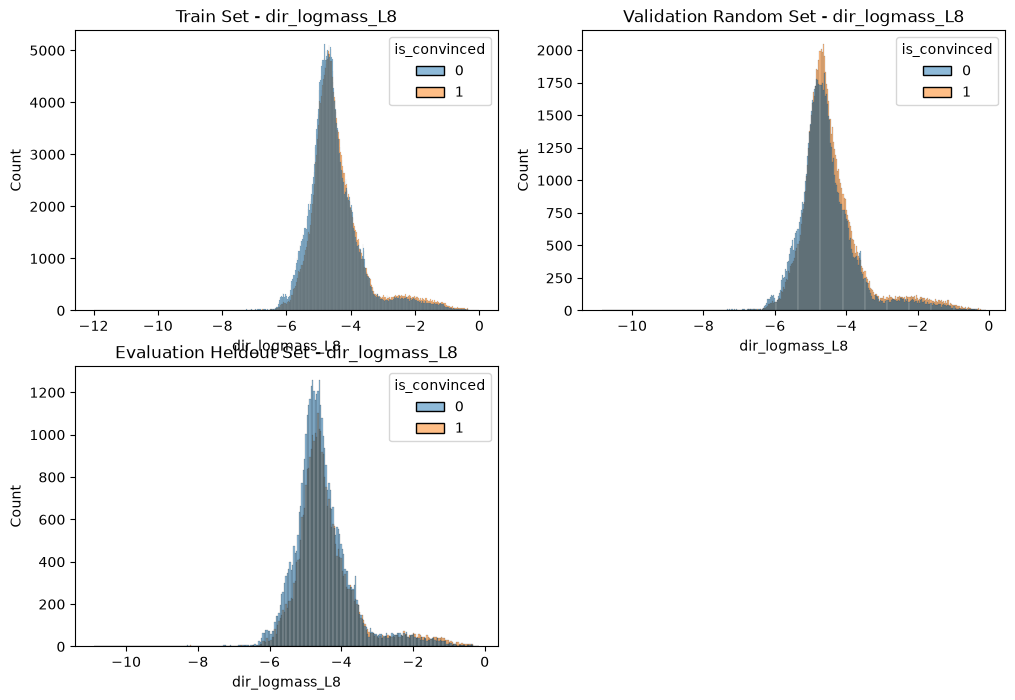

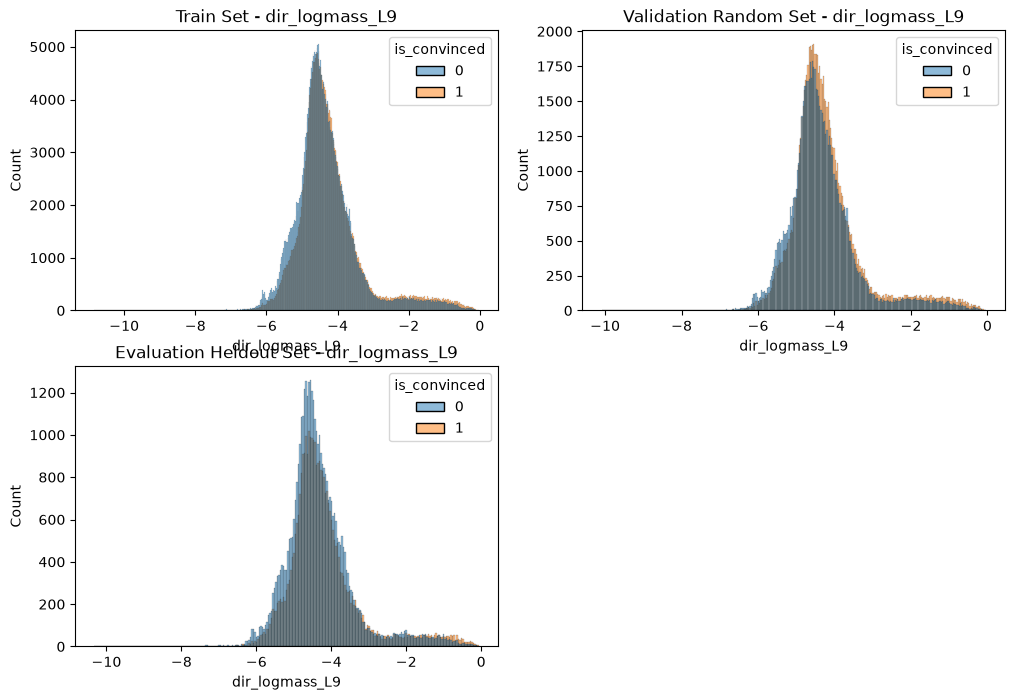

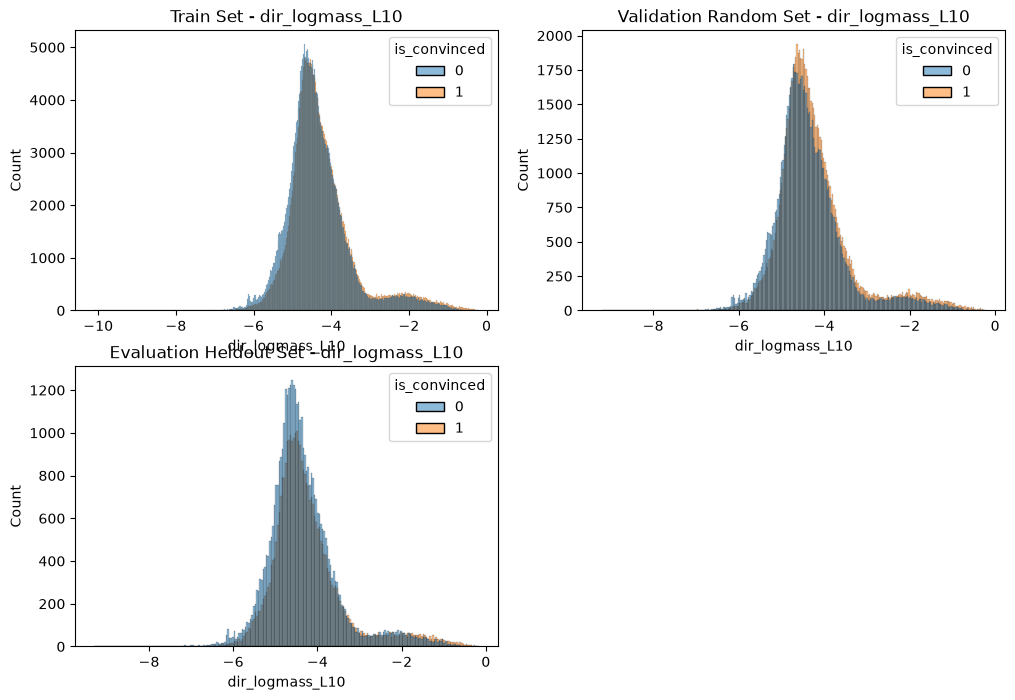

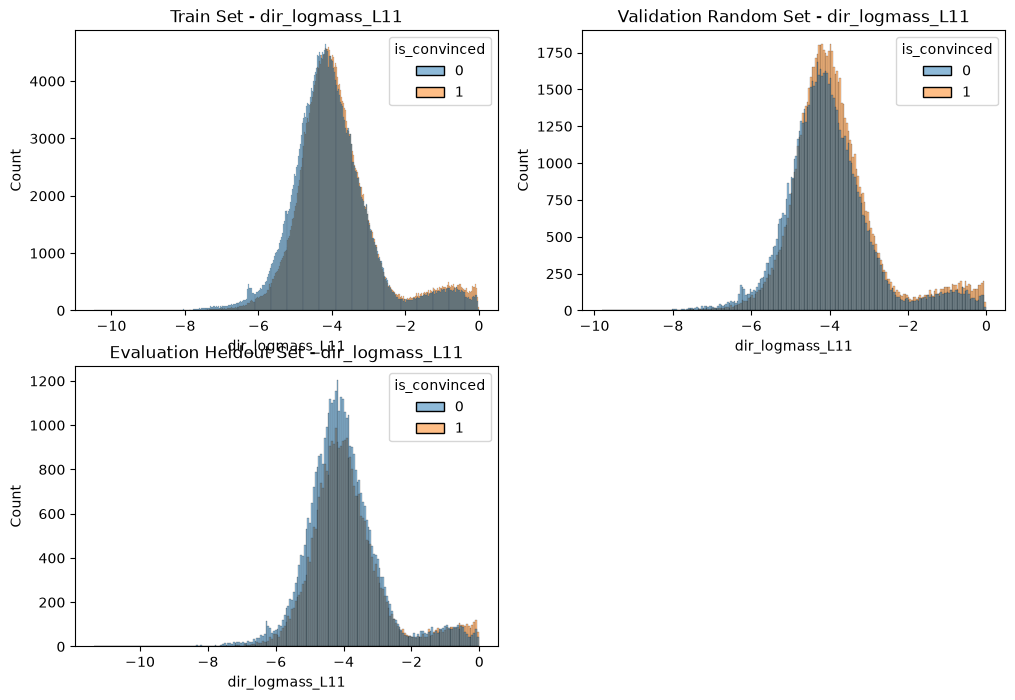

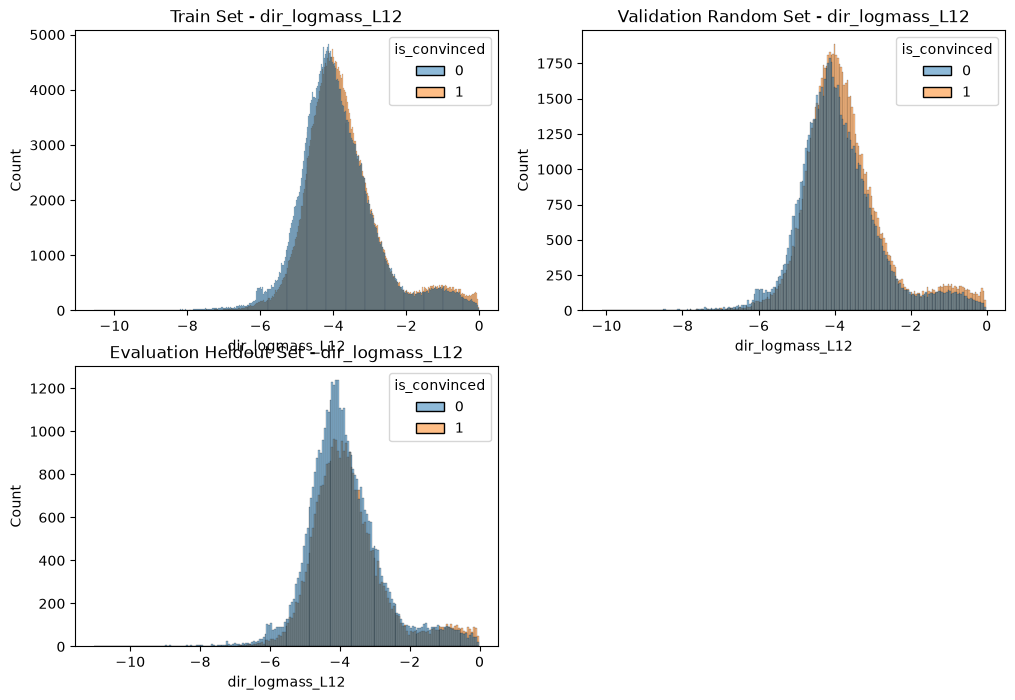

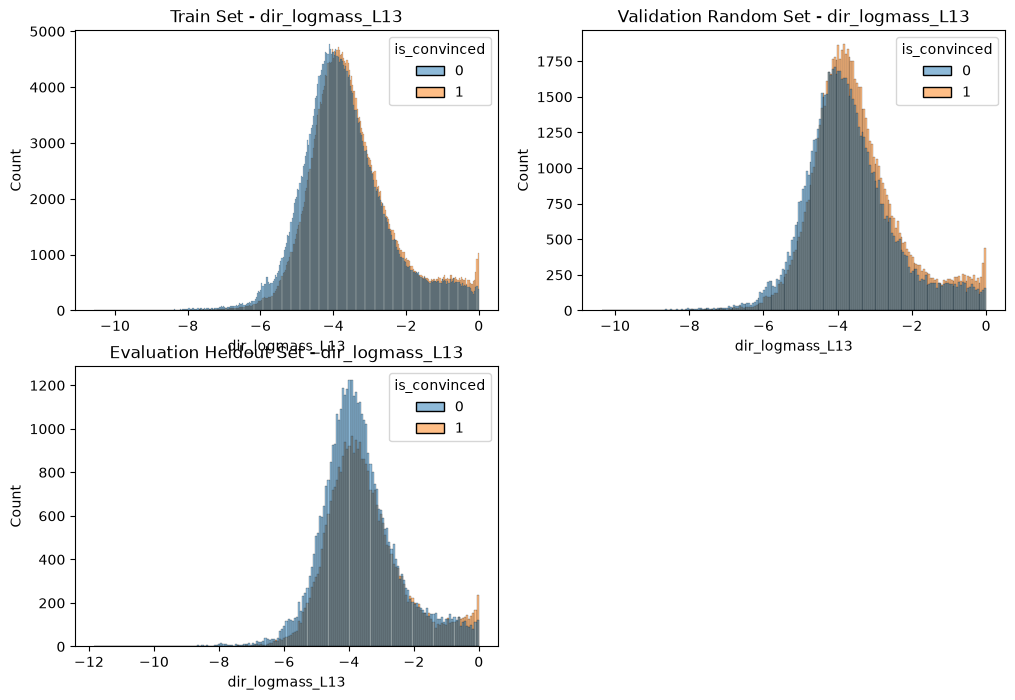

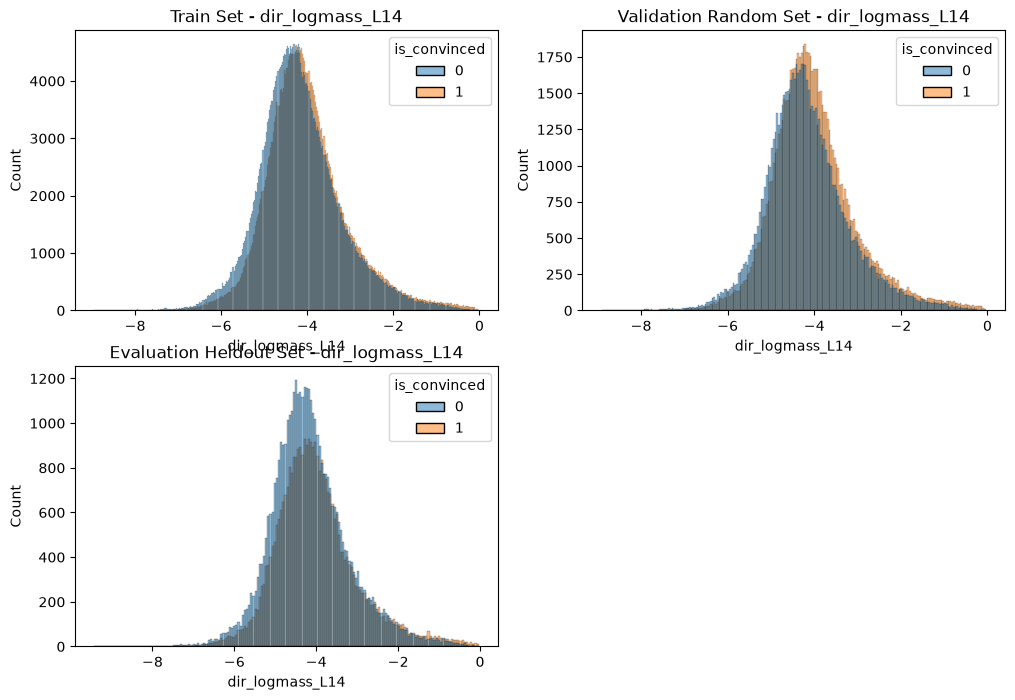

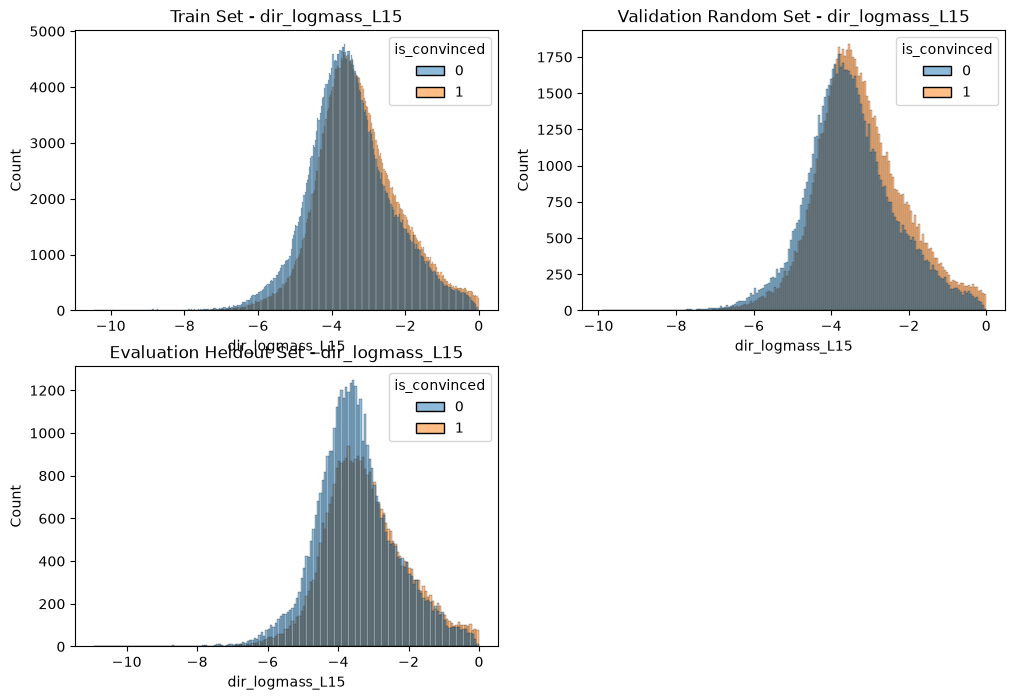

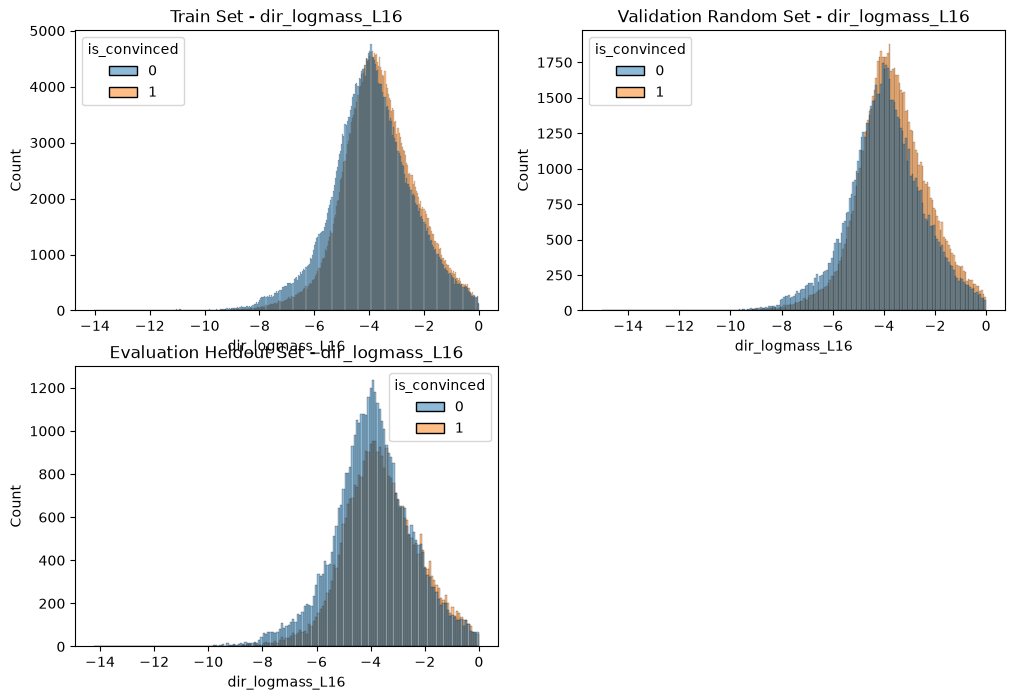

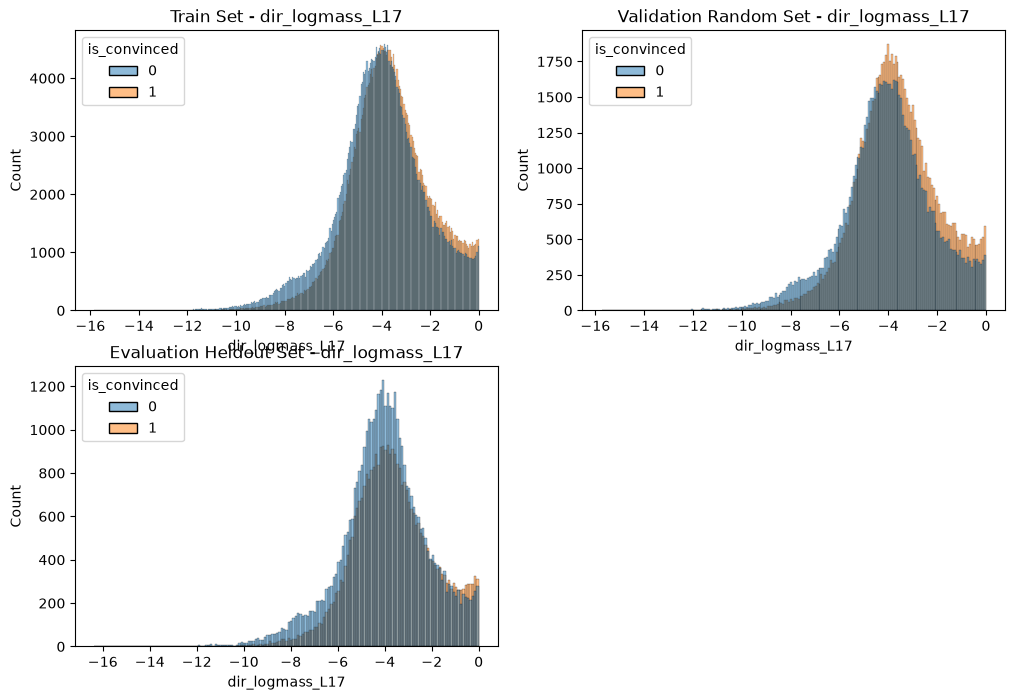

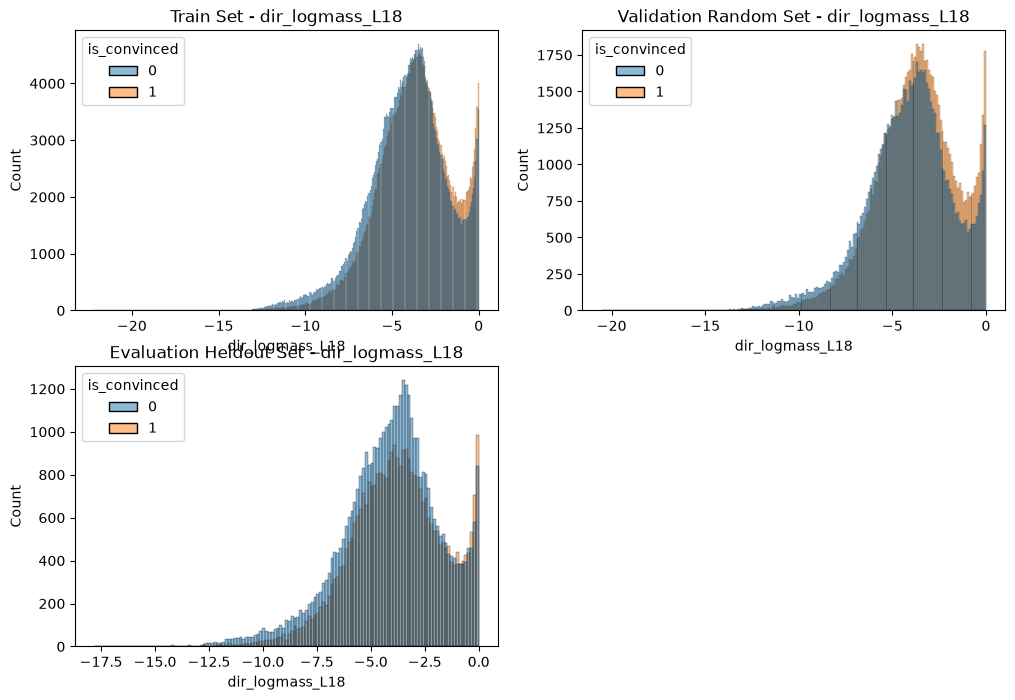

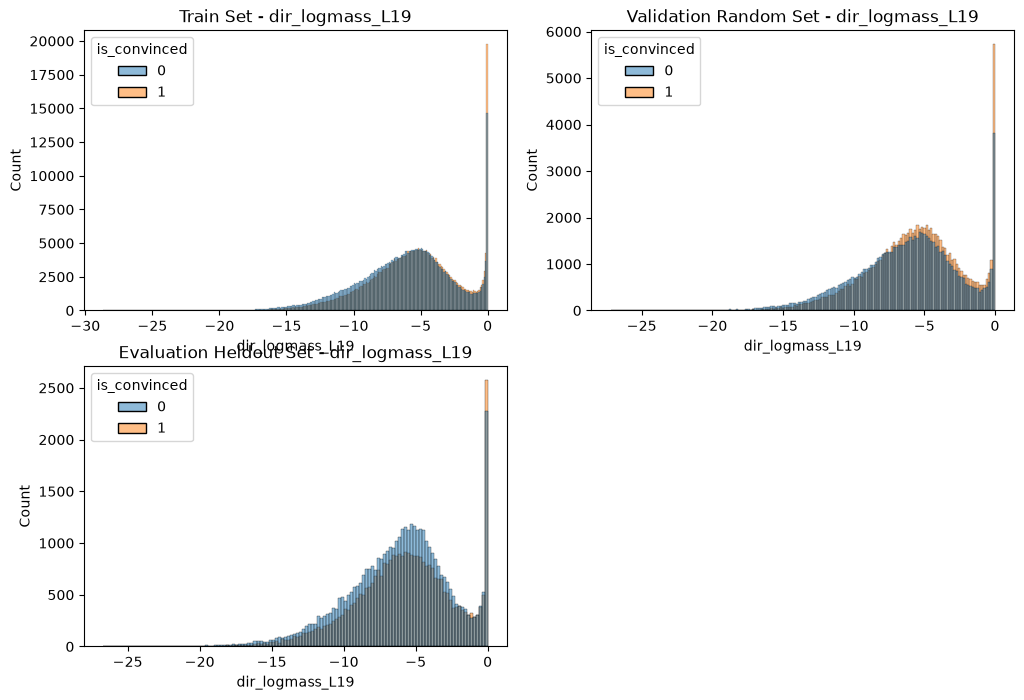

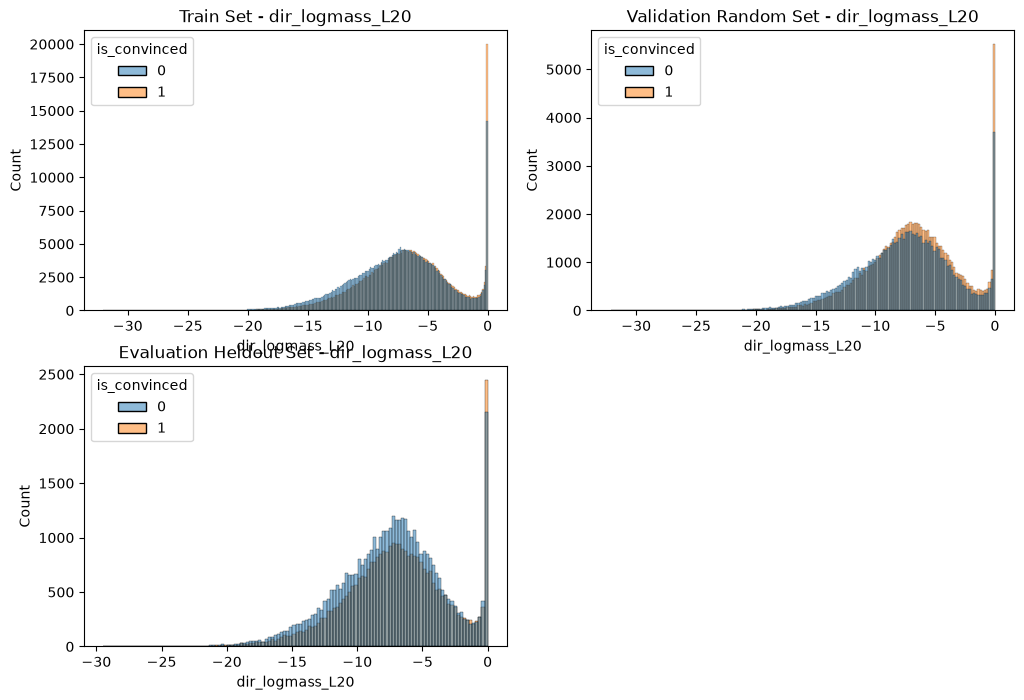

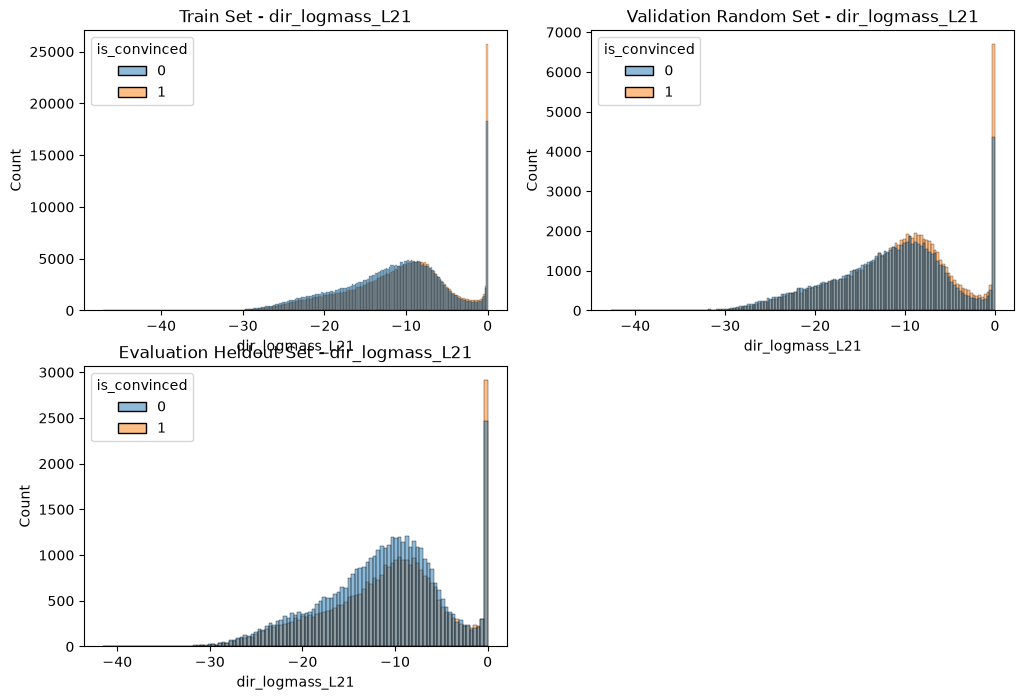

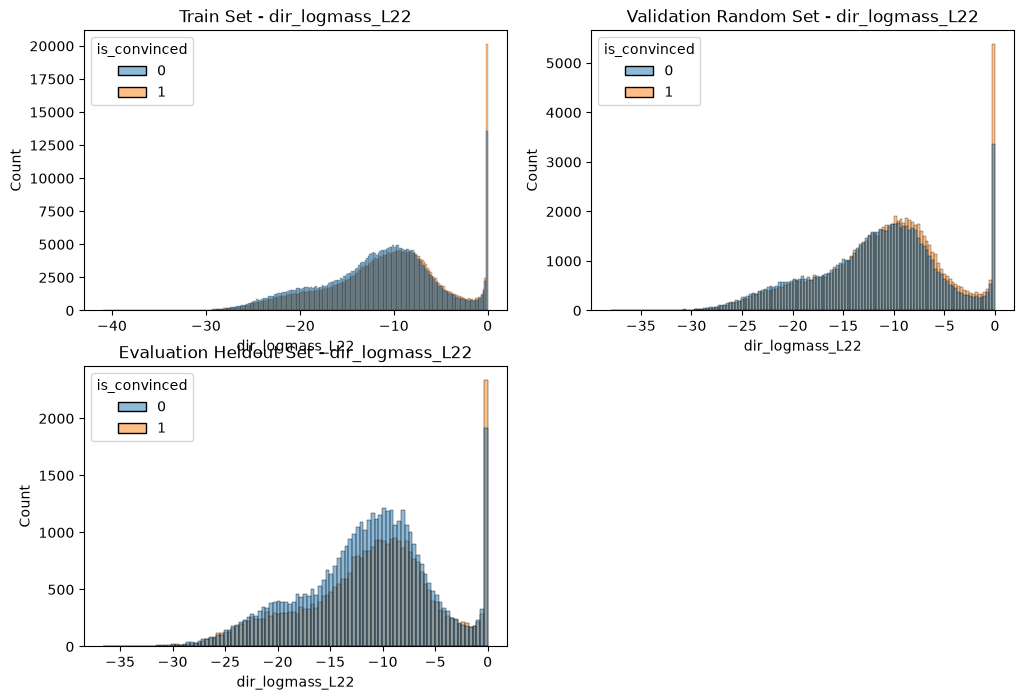

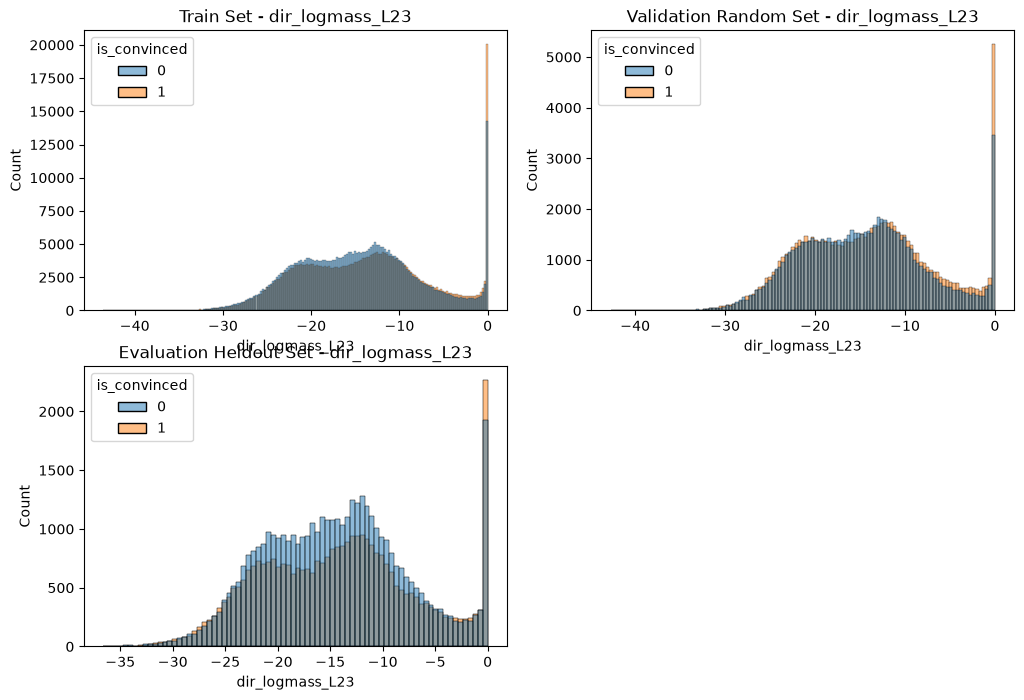

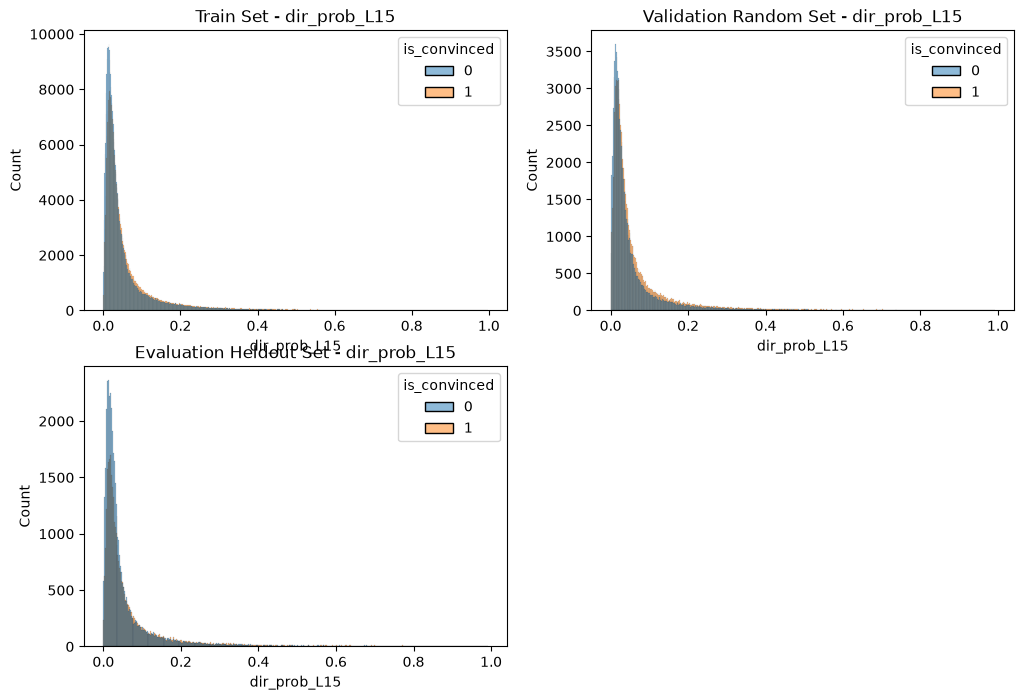

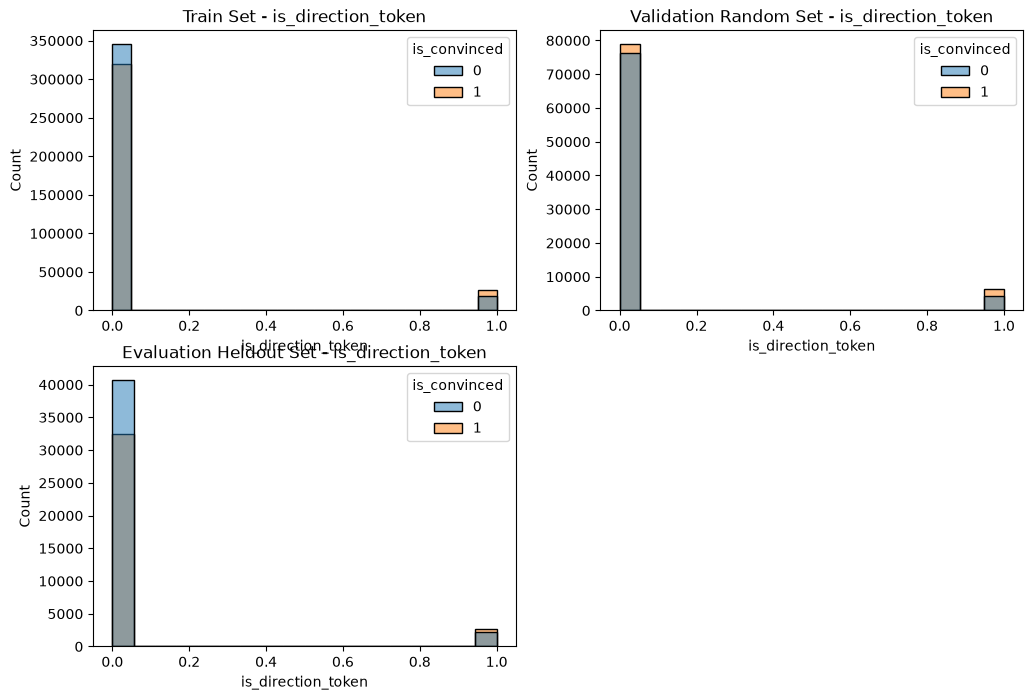

In [11]:
loudness_columns = ['dir_logmass_L7', 'dir_logmass_L8', 'dir_logmass_L9',
       'dir_logmass_L10', 'dir_logmass_L11', 'dir_logmass_L12',
       'dir_logmass_L13', 'dir_logmass_L14', 'dir_logmass_L15',
       'dir_logmass_L16', 'dir_logmass_L17', 'dir_logmass_L18',
       'dir_logmass_L19', 'dir_logmass_L20', 'dir_logmass_L21',
       'dir_logmass_L22', 'dir_logmass_L23']
l15 = 'dir_logmass_L15'
l15_prob = 'dir_prob_L15'
is_direction_token = 'is_direction_token'

for col in loudness_columns + [l15_prob] + [is_direction_token]:
       plt.figure(figsize=(12, 8))
       plt.subplot(2, 2, 1)
       sns.histplot(data=df_train_normal, x=col, hue='is_convinced', multiple='layer')
       plt.title(f'Train Set - {col}')
       plt.subplot(2, 2, 2)
       sns.histplot(data=df_val_normal, x=col, hue='is_convinced', multiple='layer')
       plt.title(f'Validation Random Set - {col}')
       plt.subplot(2, 2, 3)
       sns.histplot(data=eval_heldout_normal, x=col, hue='is_convinced', multiple='layer')
       plt.title(f'Evaluation Heldout Set - {col}')

# Classifiers

In [12]:
from sklearn.metrics import balanced_accuracy_score

def get_data(df, columns, label):
    X = df[columns]
    y = df[label]
    return X, y

def train_model(X_train, y_train, model=LogisticRegression(max_iter=1000)):
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    unique, counts = np.unique(y_pred, return_counts=True)
    accuracy = np.mean(y_pred == y_test)
    print(f"Predicted class distribution: {dict(zip(unique, counts))}")
    print(f"Actual class distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}")
    return accuracy

def eval_balanced_accuracy(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return balanced_accuracy_score(y_test, y_pred)

def train_and_validate(df_train, df_val, columns, label, model=LogisticRegression(max_iter=1000)):
    # Get training data
    X_train, y_train = get_data(df_train, columns, label)
    
    # Train the model
    model = train_model(X_train, y_train, model=model)
    
    # Get validation data for val1
    X_val, y_val = get_data(df_val, columns, label)
    val_accuracy = evaluate_model(model, X_val, y_val)
    train_acc = evaluate_model(model, X_train, y_train)
    val_balanced_accuracy = eval_balanced_accuracy(model, X_val, y_val)
    train_balanced_accuracy = eval_balanced_accuracy(model, X_train, y_train)
    
    return {
        'model': model,
        'val_accuracy': val_accuracy,
        'train_accuracy': train_acc,
        'val_balanced_accuracy': val_balanced_accuracy,
        'train_balanced_accuracy': train_balanced_accuracy
    }

def print_results(results):
    print(f"Validation Data Accuracy: {results['val_accuracy']:.4f}")
    print(f"Validation Data Balanced Accuracy: {results['val_balanced_accuracy']:.4f}")
    print(f"Training Data Accuracy: {results['train_accuracy']:.4f}")
    print(f"Training Data Balanced Accuracy: {results['train_balanced_accuracy']:.4f}")

def full_analysis(df_train, df_val, columns, label, model=LogisticRegression(max_iter=1000)):
    results = train_and_validate(df_train, df_val, columns, label, model=model)
    print_results(results)
    return results

## Classifier based on L15

In [13]:
columns = [l15]
label = 'is_convinced'

df_train_normal[columns + [label]].head()

,dir_logmass_L15,is_convinced
0,-4.131310,0
1,-3.627254,0
2,-4.915357,0
3,-4.650025,0
4,-4.100056,0


In [14]:
results = full_analysis(df_train_normal, df_val_normal, columns, label)

Predicted class distribution: {np.int64(0): np.int64(106130), np.int64(1): np.int64(59824)}
Actual class distribution: {np.int64(0): np.int64(80582), np.int64(1): np.int64(85372)}
Predicted class distribution: {np.int64(0): np.int64(456433), np.int64(1): np.int64(254641)}
Actual class distribution: {np.int64(0): np.int64(364634), np.int64(1): np.int64(346440)}
Validation Data Accuracy: 0.5356
Validation Data Balanced Accuracy: 0.5396
Training Data Accuracy: 0.5382
Training Data Balanced Accuracy: 0.5346


/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


## Classifier based on all layers loudness

In [15]:
columns = loudness_columns
label = 'is_convinced'

df_train_normal[columns + [label]].head()

,dir_logmass_L7,dir_logmass_L8,dir_logmass_L9,dir_logmass_L10,dir_logmass_L11,dir_logmass_L12,dir_logmass_L13,dir_logmass_L14,dir_logmass_L15,dir_logmass_L16,dir_logmass_L17,dir_logmass_L18,dir_logmass_L19,dir_logmass_L20,dir_logmass_L21,dir_logmass_L22,dir_logmass_L23,is_convinced
0,-5.490474,-5.138801,-5.515247,-5.183795,-5.089465,-4.676018,-4.657405,-4.695374,-4.131310,-4.735552,-4.717509,-4.414603,-6.279967,-6.561994,-8.695574,-7.140208,-10.608364,0
1,-4.474701,-4.043456,-4.166196,-4.114516,-4.118446,-4.001261,-4.194147,-4.127795,-3.627254,-4.975793,-5.310721,-6.901892,-8.460486,-8.900504,-11.544050,-10.917677,-14.058624,0
2,-4.853863,-4.511747,-4.399899,-4.644575,-4.640572,-4.482619,-4.407492,-5.141531,-4.915357,-5.992331,-8.528085,-7.492168,-9.699778,-9.077367,-14.219599,-15.157043,-15.905306,0
3,-4.535645,-4.405145,-4.168502,-4.418431,-3.793245,-3.958932,-4.229890,-4.761874,-4.650025,-5.812133,-5.982564,-5.374652,-8.035025,-7.529011,-7.127693,-9.396303,-16.314293,0
4,-4.478479,-4.196771,-3.903967,-4.089502,-4.167325,-3.949471,-3.683978,-4.297703,-4.100056,-4.318079,-4.441293,-4.784457,-8.147236,-12.303352,-17.539736,-17.655399,-19.448101,0


In [16]:
results_full_layers = full_analysis(df_train_normal, df_val, columns, label)

/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn

Predicted class distribution: {np.int64(0): np.int64(112030), np.int64(1): np.int64(73983)}
Actual class distribution: {np.int64(0): np.int64(80582), np.int64(1): np.int64(105431)}
Predicted class distribution: {np.int64(0): np.int64(428327), np.int64(1): np.int64(282747)}
Actual class distribution: {np.int64(0): np.int64(364634), np.int64(1): np.int64(346440)}
Validation Data Accuracy: 0.5317
Validation Data Balanced Accuracy: 0.5461
Training Data Accuracy: 0.5503
Training Data Balanced Accuracy: 0.5477


/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py

# Analysis at sentence level

In [18]:
def prepare_df(df):
    df_exp = df[['name', 'size', 'complexity', 'run', 'sentence_idx'] + columns + [label, l15_prob]]
    df_exp[loudness_columns] = np.exp(df_exp[loudness_columns])
    df_per_sentence = df_exp.groupby(['name', 'size', 'complexity', 'run', 'sentence_idx'])[columns + [label, l15_prob]].mean().reset_index()
    df_per_sentence[loudness_columns] = np.log(df_per_sentence[loudness_columns])
    return df_per_sentence[loudness_columns + [l15_prob, 'is_convinced']]

df_train_per_sentence = prepare_df(df_train_normal)
df_val_per_sentence = prepare_df(df_val_normal)
df_eval_heldout_per_sentence = prepare_df(eval_heldout_normal)


/var/folders/qs/0q06h0s57kl03gnbz11ds7cw0000gn/T/ipykernel_29848/379448295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp[loudness_columns] = np.exp(df_exp[loudness_columns])
/var/folders/qs/0q06h0s57kl03gnbz11ds7cw0000gn/T/ipykernel_29848/379448295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exp[loudness_columns] = np.exp(df_exp[loudness_columns])
/var/folders/qs/0q06h0s57kl03gnbz11ds7cw0000gn/T/ipykernel_29848/379448295.py:3: SettingWithCopyWarning: 
A value is trying to be set on a

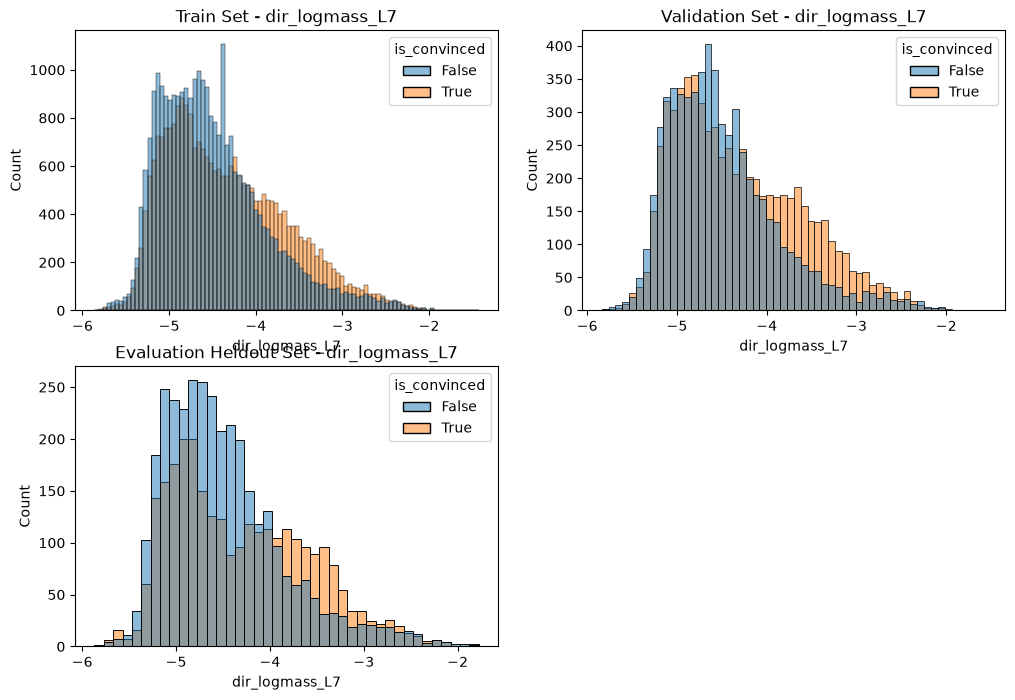

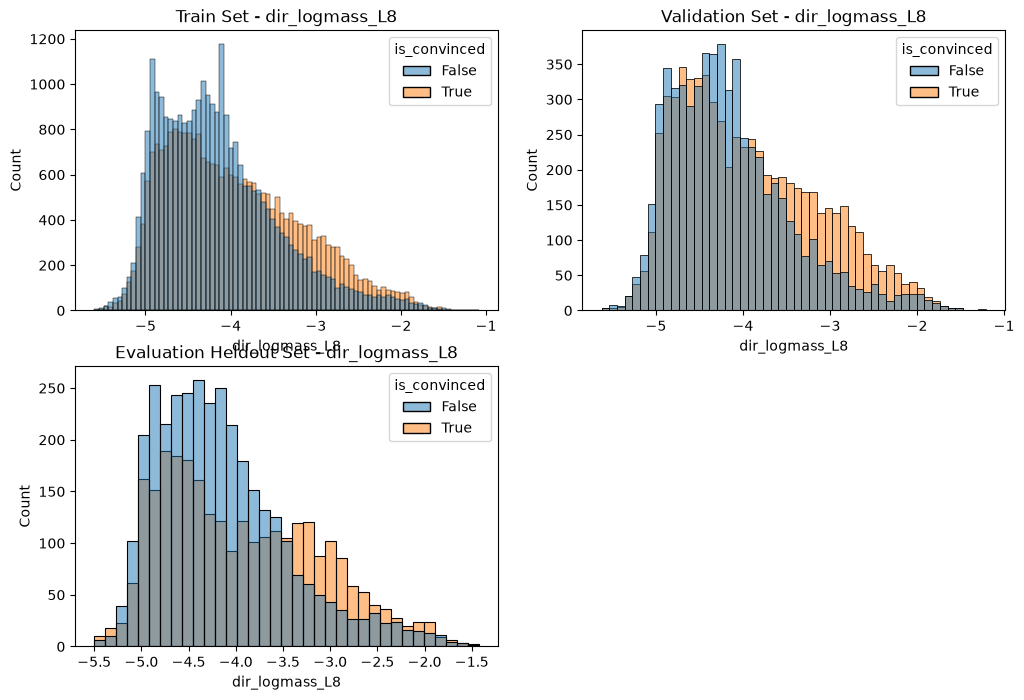

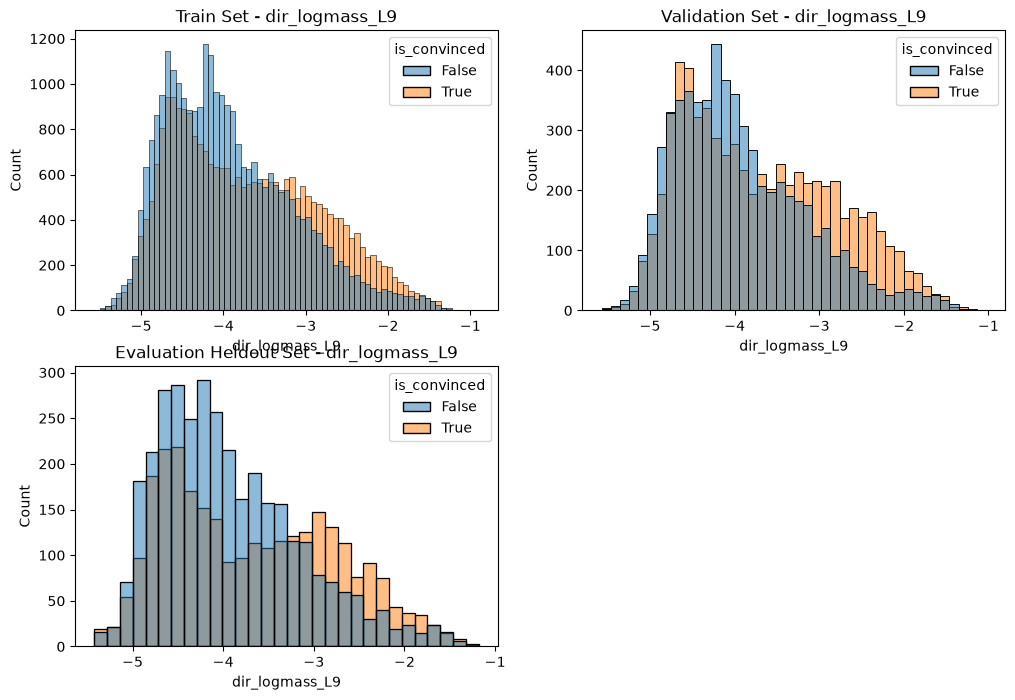

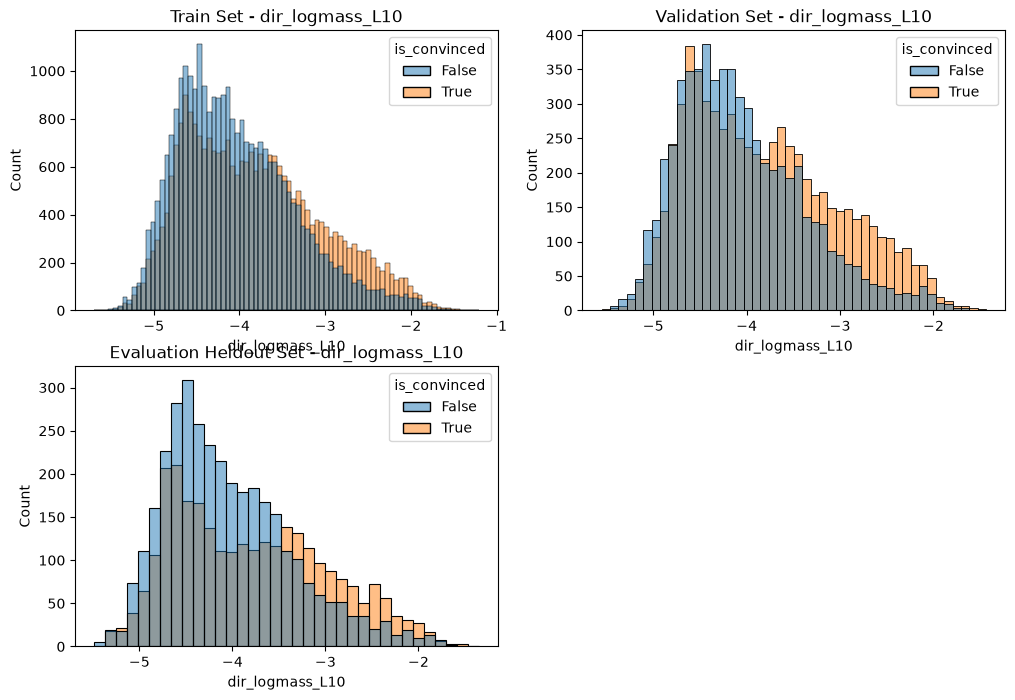

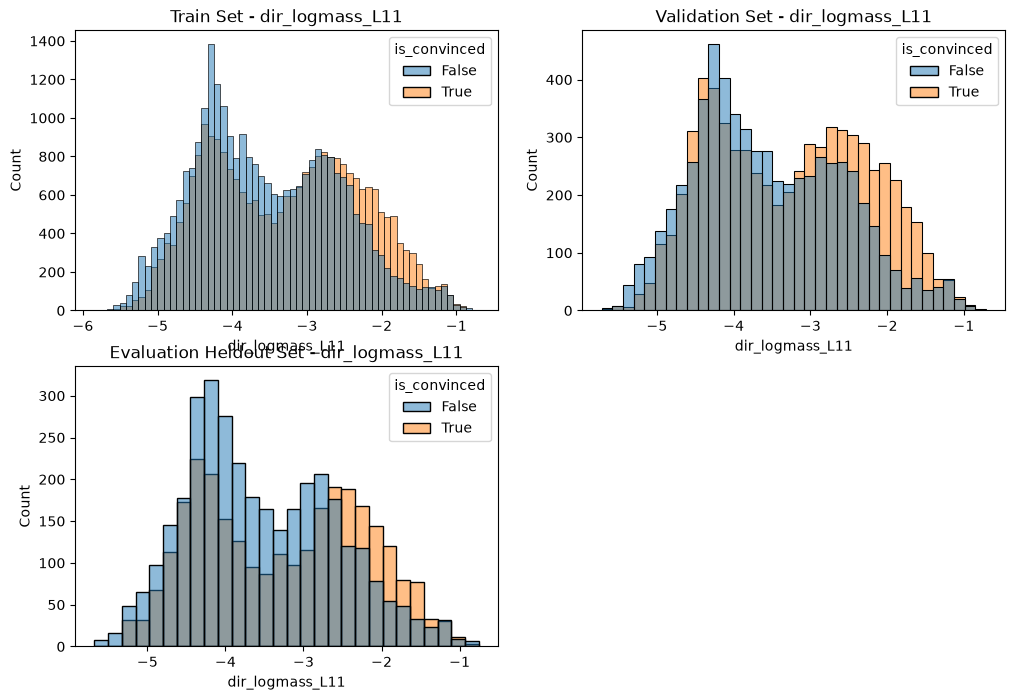

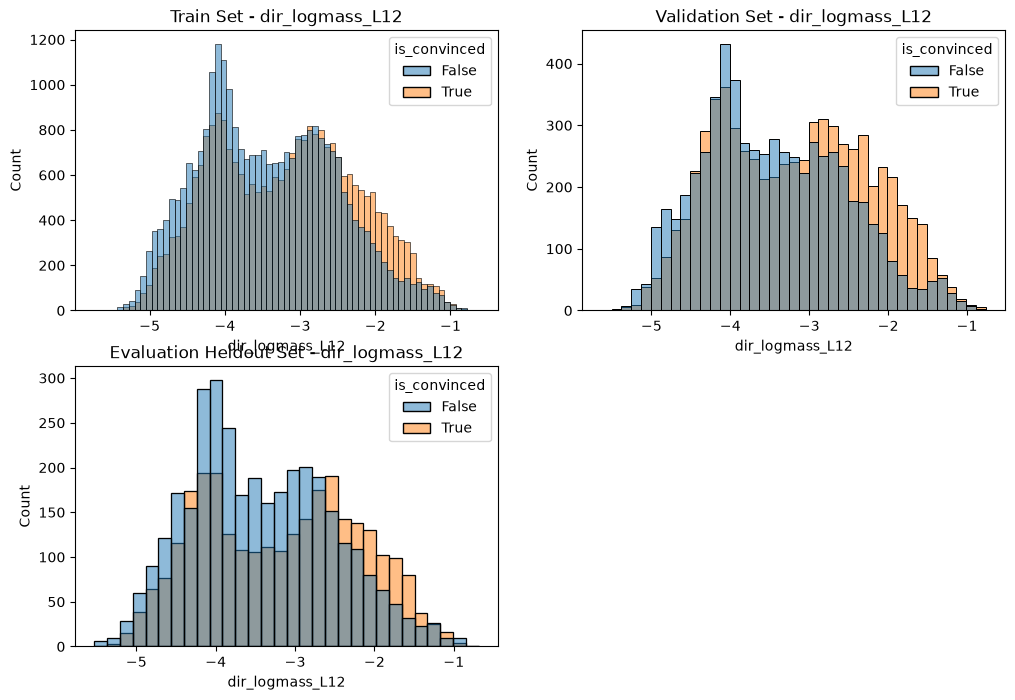

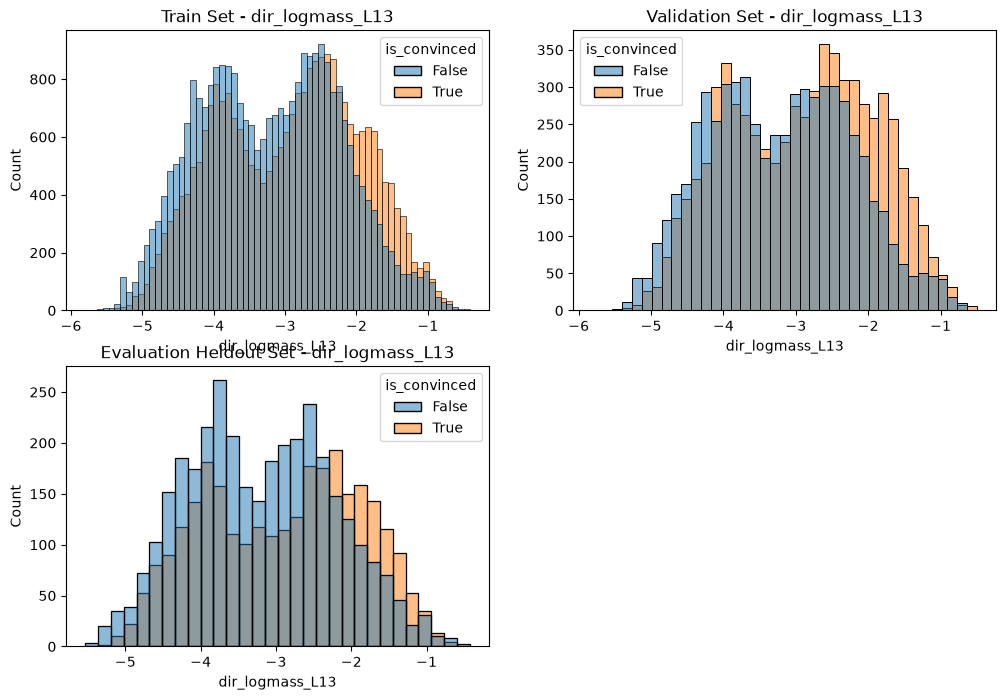

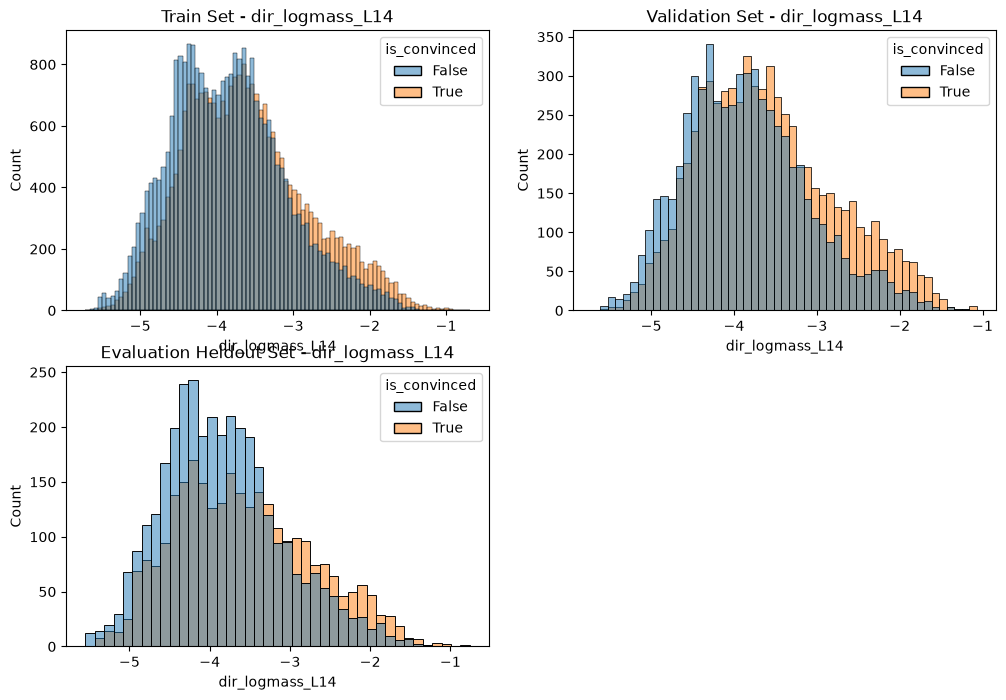

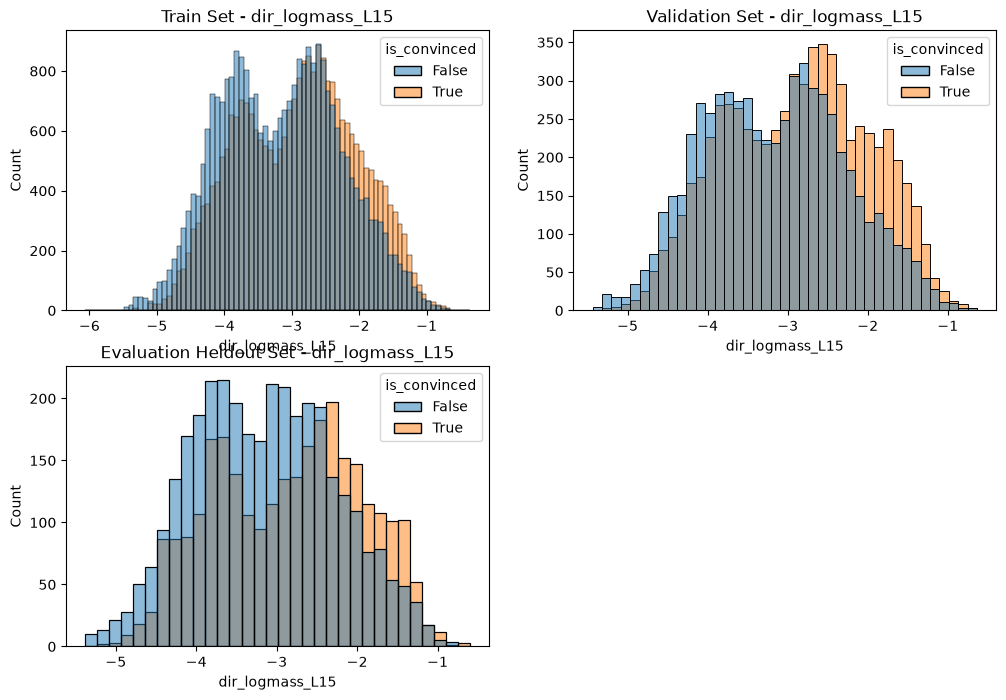

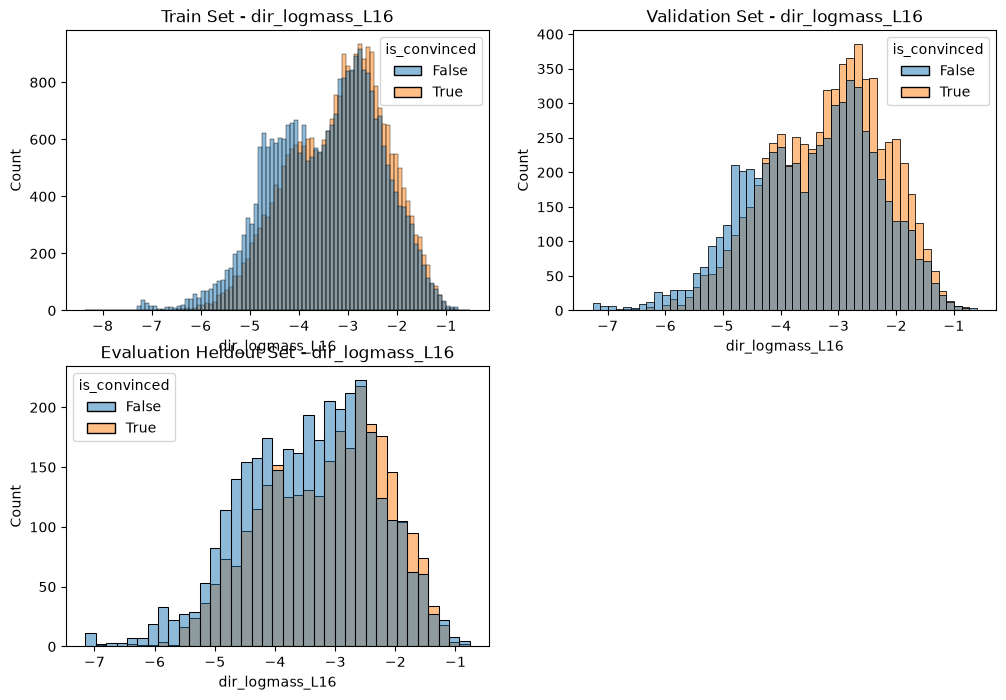

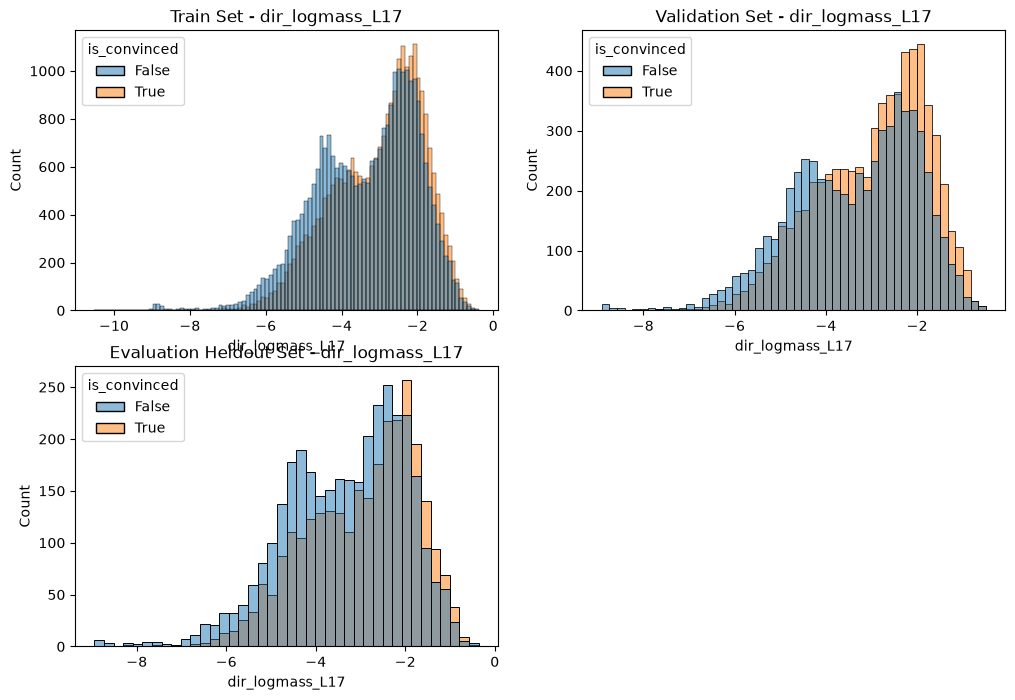

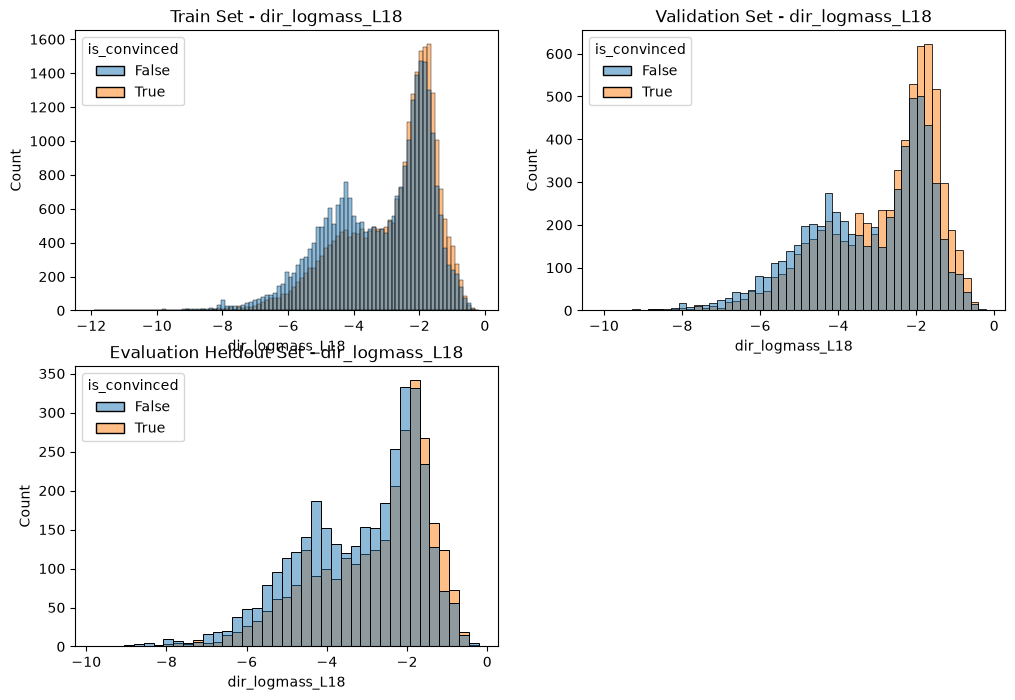

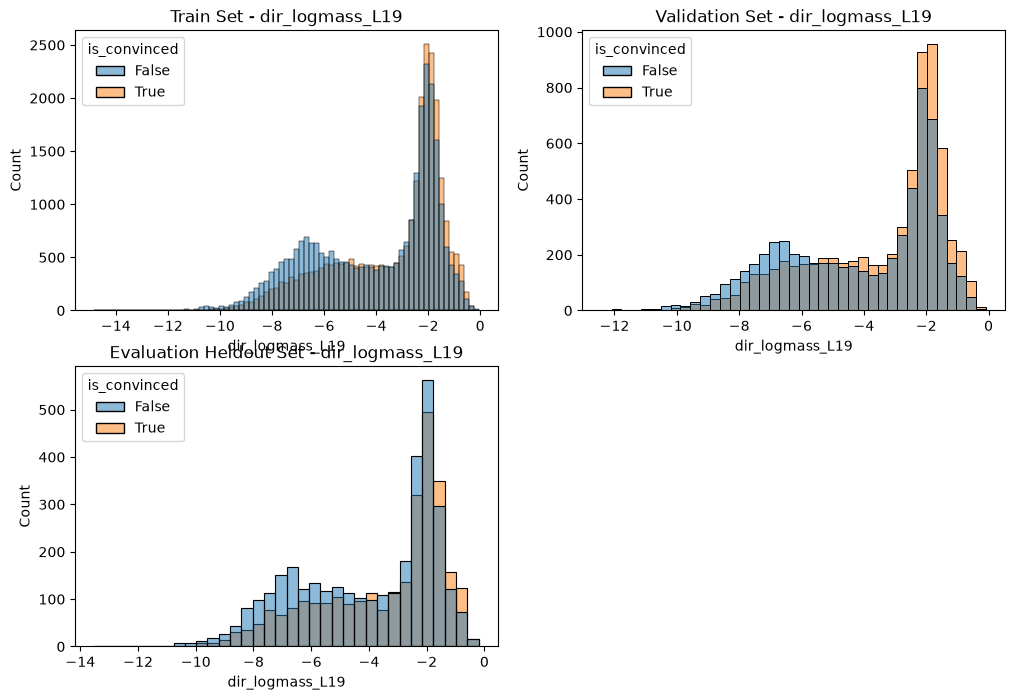

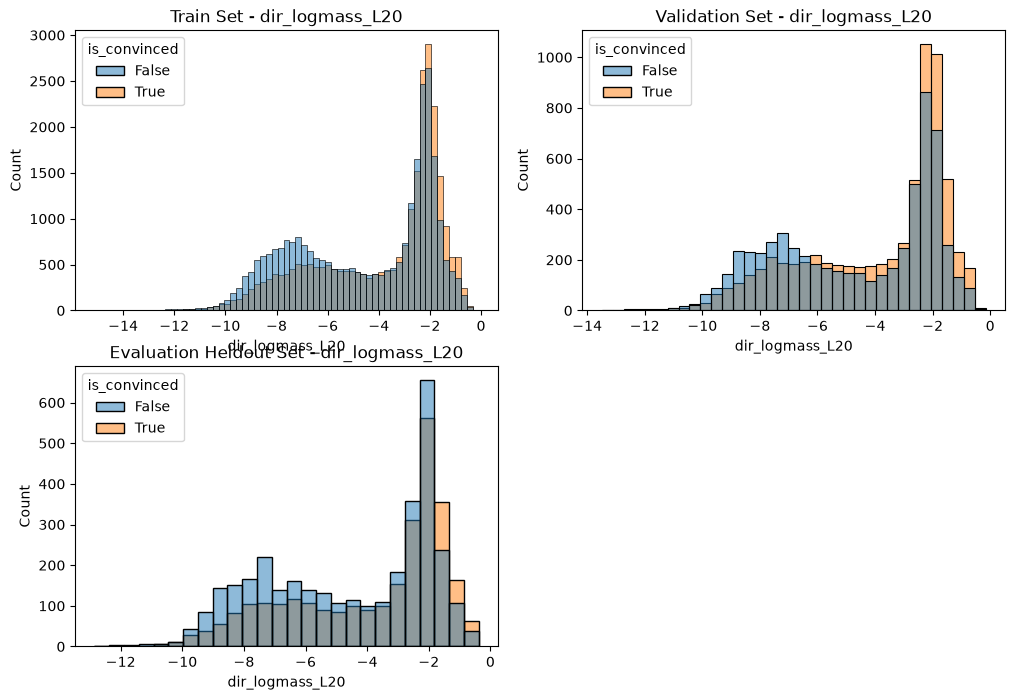

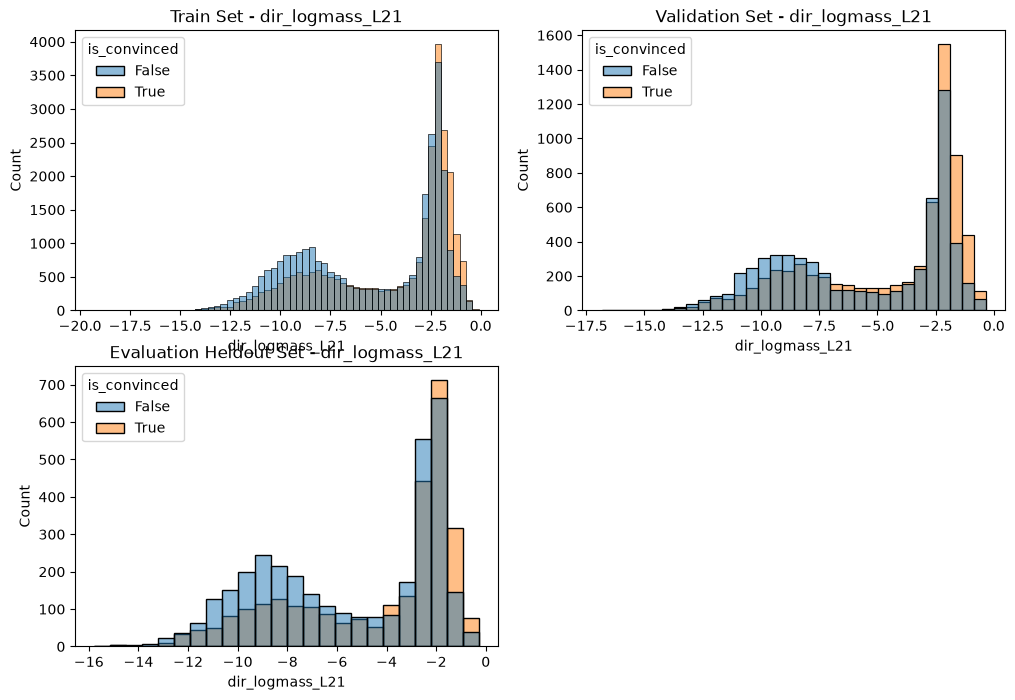

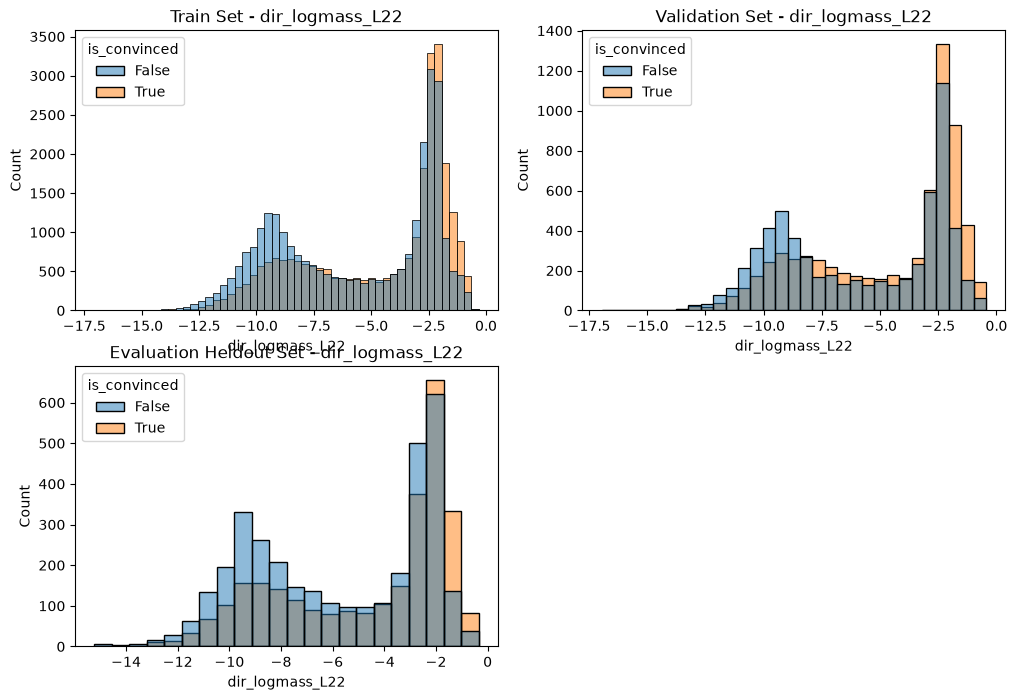

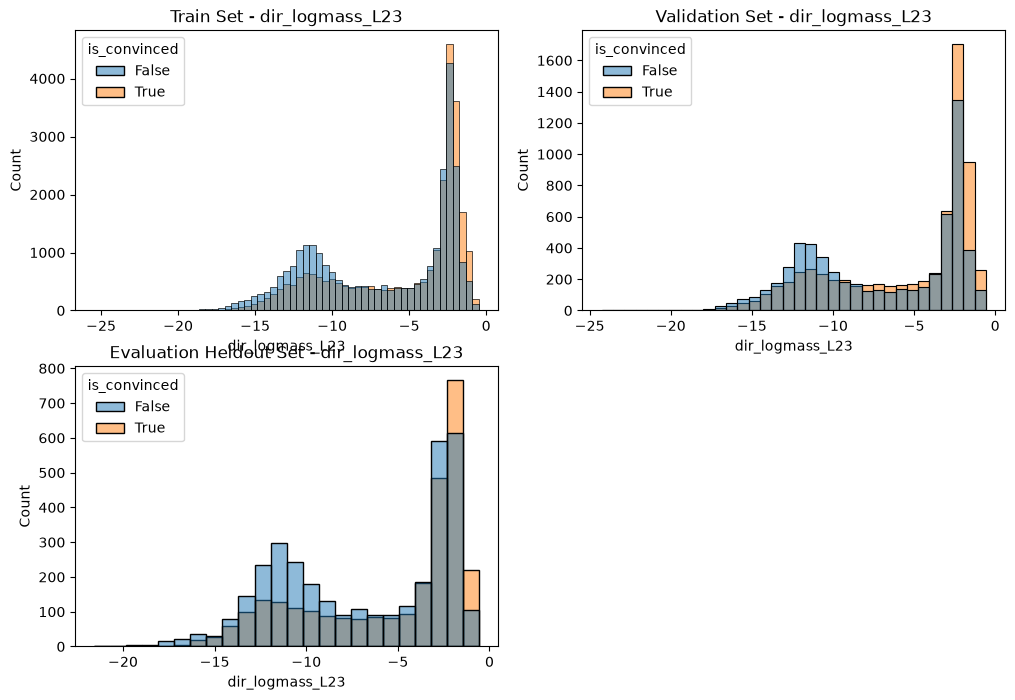

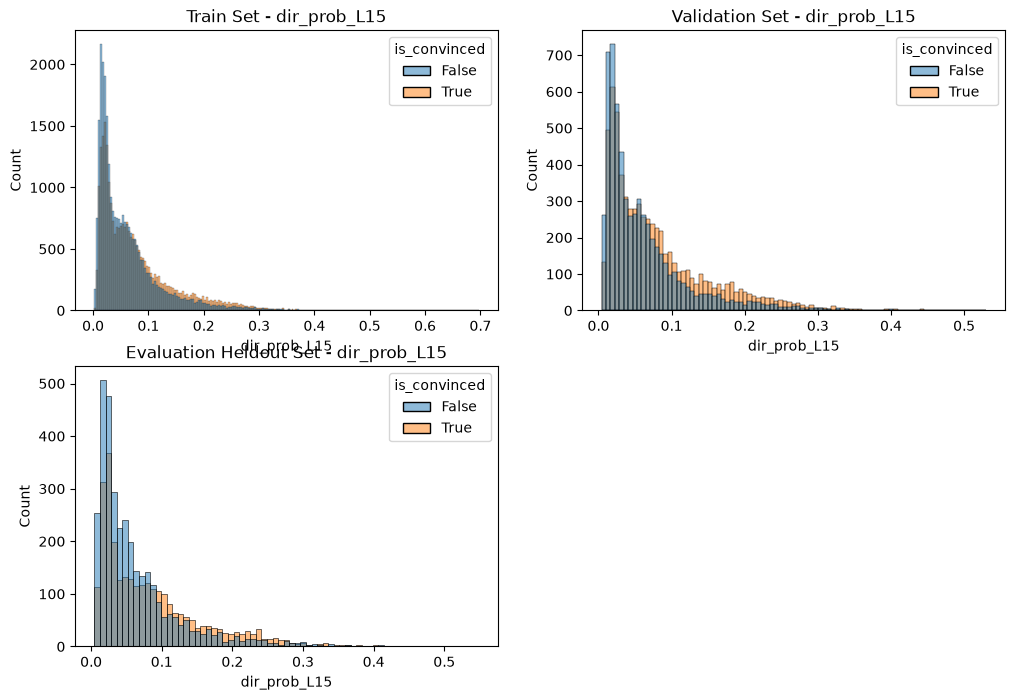

In [22]:
for col in loudness_columns + [l15_prob]:
       plt.figure(figsize=(12, 8))
       plt.subplot(2, 2, 1)
       sns.histplot(data=df_train_per_sentence, x=col, hue=df_train_per_sentence['is_convinced']>=0.5)
       plt.title(f'Train Set - {col}')
       plt.subplot(2, 2, 2)
       sns.histplot(data=df_val_per_sentence, x=col, hue=df_val_per_sentence['is_convinced']>=0.5)
       plt.title(f'Validation Set - {col}')
       plt.subplot(2, 2, 3)
       sns.histplot(data=df_eval_heldout_per_sentence, x=col, hue=df_eval_heldout_per_sentence['is_convinced']>=0.5)
       plt.title(f'Evaluation Heldout Set - {col}')

In [23]:
df_train_per_sentence['is_convinced_int'] = (df_train_per_sentence['is_convinced'] >= 0.5).astype(int)
df_val_per_sentence['is_convinced_int'] = (df_val_per_sentence['is_convinced'] >= 0.5).astype(int)
df_eval_heldout_per_sentence['is_convinced_int'] = (df_eval_heldout_per_sentence['is_convinced'] >= 0.5).astype(int)

In [24]:
label = 'is_convinced_int'
full_analysis(df_train_per_sentence, df_val_per_sentence, columns, label)

/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn

Predicted class distribution: {np.int64(0): np.int64(7156), np.int64(1): np.int64(5678)}
Actual class distribution: {np.int64(0): np.int64(6136), np.int64(1): np.int64(6698)}
Predicted class distribution: {np.int64(0): np.int64(30972), np.int64(1): np.int64(23901)}
Actual class distribution: {np.int64(0): np.int64(28212), np.int64(1): np.int64(26661)}
Validation Data Accuracy: 0.5789
Validation Data Balanced Accuracy: 0.5816
Training Data Accuracy: 0.5802
Training Data Balanced Accuracy: 0.5785


/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/alexdimofte/workspace/northeastern/interp/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py

{'model': LogisticRegression(max_iter=1000),
 'val_accuracy': np.float64(0.5789309646252143),
 'train_accuracy': np.float64(0.5802307145590727),
 'val_balanced_accuracy': 0.5816089412356449,
 'train_balanced_accuracy': 0.5784722600798522}

# Random Forest Analysis

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

full_analysis(df_train_per_sentence, df_val_per_sentence, columns, label, model=model)
print('')
full_analysis(df_train_per_sentence, df_val_per_sentence, [l15], label, model=model)

Predicted class distribution: {np.int64(0): np.int64(7110), np.int64(1): np.int64(5724)}
Actual class distribution: {np.int64(0): np.int64(6136), np.int64(1): np.int64(6698)}
Predicted class distribution: {np.int64(0): np.int64(28212), np.int64(1): np.int64(26661)}
Actual class distribution: {np.int64(0): np.int64(28212), np.int64(1): np.int64(26661)}
Validation Data Accuracy: 0.6310
Validation Data Balanced Accuracy: 0.6336
Training Data Accuracy: 1.0000
Training Data Balanced Accuracy: 1.0000

Predicted class distribution: {np.int64(0): np.int64(6556), np.int64(1): np.int64(6278)}
Actual class distribution: {np.int64(0): np.int64(6136), np.int64(1): np.int64(6698)}
Predicted class distribution: {np.int64(0): np.int64(28223), np.int64(1): np.int64(26650)}
Actual class distribution: {np.int64(0): np.int64(28212), np.int64(1): np.int64(26661)}
Validation Data Accuracy: 0.5121
Validation Data Balanced Accuracy: 0.5126
Training Data Accuracy: 0.9988
Training Data Balanced Accuracy: 0.9988

{'model': RandomForestClassifier(random_state=42),
 'val_accuracy': np.float64(0.5120772946859904),
 'train_accuracy': np.float64(0.9987789987789988),
 'val_balanced_accuracy': 0.5125756808060784,
 'train_balanced_accuracy': 0.9987723518427589}

In [28]:
full_analysis(df_train_per_sentence, df_val_per_sentence, columns+[l15_prob], label, model=model)

Predicted class distribution: {np.int64(0): np.int64(7110), np.int64(1): np.int64(5724)}
Actual class distribution: {np.int64(0): np.int64(6136), np.int64(1): np.int64(6698)}
Predicted class distribution: {np.int64(0): np.int64(28212), np.int64(1): np.int64(26661)}
Actual class distribution: {np.int64(0): np.int64(28212), np.int64(1): np.int64(26661)}
Validation Data Accuracy: 0.6213
Validation Data Balanced Accuracy: 0.6239
Training Data Accuracy: 1.0000
Training Data Balanced Accuracy: 1.0000


{'model': RandomForestClassifier(random_state=42),
 'val_accuracy': np.float64(0.6213183730715287),
 'train_accuracy': np.float64(1.0),
 'val_balanced_accuracy': 0.6239205314552243,
 'train_balanced_accuracy': 1.0}